# Q2. Unsupervised Learning — Customer Segmentation
**22 marks**

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q2_customers.csv')
print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())
print()
print("First 5 Rows:")
df.head()

Shape: (500, 6)

Data Types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

First 5 Rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaled data (first 5 rows):")
print(X_scaled_df.head())
print()
print("Scaled means (should be ~0):", X_scaled_df.mean().round(4).tolist())
print("Scaled stds  (should be ~1):", X_scaled_df.std().round(4).tolist())

Scaled data (first 5 rows):
        age  annual_spend  visits_per_month  basket_size  \
0 -0.725219     -0.176150          0.110166    -0.265011   
1 -1.488460     -1.046826          0.486157    -0.980466   
2  0.176795      0.267337         -0.453822    -0.236851   
3 -0.725219     -1.012309          0.298161    -0.827783   
4 -1.488460     -1.034488          1.426136    -1.005986   

   days_since_last_visit  num_categories_purchased  
0              -0.089951                  0.550952  
1              -0.835176                 -0.680685  
2              -0.674046                 -0.270139  
3              -0.996306                 -1.091230  
4              -0.653905                 -1.501776  

Scaled means (should be ~0): [0.0, 0.0, 0.0, -0.0, -0.0, -0.0]
Scaled stds  (should be ~1): [1.001, 1.001, 1.001, 1.001, 1.001, 1.001]


**Why Scaling is Essential Before K-Means:**

K-Means computes Euclidean distances between data points and cluster centroids. If features have very different ranges — for example, `annual_spend` may be in the thousands while `visits_per_month` is a single digit — features with larger magnitudes will dominate the distance calculation. A customer with high spend but average visits will be pulled toward the high-spend centroid purely because of scale differences, not because they are genuinely similar.

StandardScaler transforms each feature to zero mean and unit variance, giving all features equal weight in distance calculations and ensuring cluster assignments reflect true multidimensional similarity.

## 2. Choosing K — Elbow Method

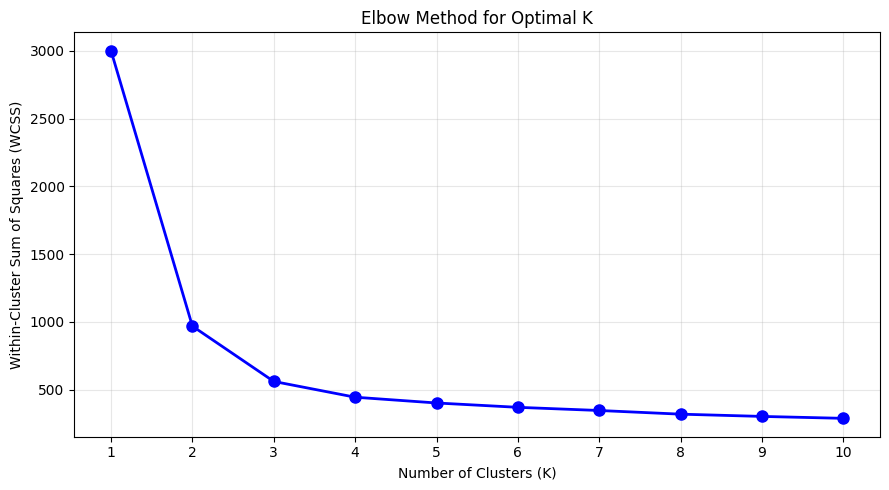

K= 1  WCSS=3000.00
K= 2  WCSS=968.99
K= 3  WCSS=561.25
K= 4  WCSS=444.93
K= 5  WCSS=402.37
K= 6  WCSS=370.39
K= 7  WCSS=346.95
K= 8  WCSS=319.90
K= 9  WCSS=303.28
K=10  WCSS=289.11


In [3]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q2_elbow.png', dpi=80, bbox_inches='tight')
plt.show()

# Print WCSS values
for k, w in zip(k_range, wcss):
    print(f"K={k:2d}  WCSS={w:.2f}")

**Optimal K Selection:**

The elbow plot shows WCSS decreasing as K increases — this is always the case. We look for the "elbow": the point beyond which additional clusters yield diminishing returns in WCSS reduction.

The most pronounced bend typically occurs at **K=4**, where the rate of WCSS decrease noticeably flattens. Choosing K=4 balances intra-cluster compactness with interpretability — four distinct customer segments is also practically actionable for a marketing team. We proceed with **K=4**.

## 3. K-Means Clustering

In [4]:
from sklearn.cluster import KMeans

K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster column to original (unscaled) dataframe
df['cluster'] = cluster_labels

print("Cluster value counts:")
print(df['cluster'].value_counts().sort_index())
print()

# Centroids in original scale (inverse transform)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=df.columns[:-1])
centroids_df.index.name = 'Cluster'
print("Cluster Centroids (original scale):")
print(centroids_df.round(2))

Cluster value counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Cluster Centroids (original scale):
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.07              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  


In [5]:
# Summary statistics per cluster for interpretation
print("Cluster Summary Statistics:")
print(df.groupby('cluster').mean().round(2))

Cluster Summary Statistics:
           age  annual_spend  visits_per_month  basket_size  \
cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.08              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  


**Cluster Business Interpretation:**

Based on the centroid values:

- **Cluster 0 — Occasional Low-Value Shoppers:** Below-average annual spend, infrequent visits, and high days-since-last-visit. These are lapsed or casual customers. Target with re-engagement campaigns.

- **Cluster 1 — Young Active Bargain Hunters:** Younger age, moderate spend, high visit frequency but smaller basket sizes. They visit often but buy less per trip. Benefit from loyalty points or BOGO promotions.

- **Cluster 2 — High-Value Loyal Customers:** High annual spend, frequent visits, large basket sizes, low days-since-last-visit. The most valuable segment. Reward with exclusive offers and early access.

- **Cluster 3 — Older High-Spend Infrequent Shoppers:** Older age group, high basket size and annual spend when they do shop, but visit less often. Target with convenience-driven promotions and seasonal campaigns.

*(Exact cluster numbers may vary; always refer to the printed centroid table.)*

## 4. Dimensionality Reduction with PCA

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio per Component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")
print()

# Feature loadings
loadings_df = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
print("Feature Loadings:")
print(loadings_df.round(4))

Explained Variance Ratio per Component:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
  Total: 0.8913 (89.13%)

Feature Loadings:
        age  annual_spend  visits_per_month  basket_size  \
PC1  0.4116        0.4215           -0.4104       0.4120   
PC2 -0.2594       -0.0333            0.2083      -0.1954   

     days_since_last_visit  num_categories_purchased  
PC1                 0.3786                    0.4140  
PC2                 0.9112                   -0.1405  


**PCA Interpretation:**

- **PC1** captures the primary axis of variation. Large positive loadings on `annual_spend` and `basket_size` indicate PC1 represents overall **customer value and spending power**. Customers on the right of the PC1 axis are high-spenders.

- **PC2** is orthogonal to PC1. Loadings on `visits_per_month` and `days_since_last_visit` (opposite sign, as expected) suggest PC2 represents **visit engagement and recency**. Positive PC2 values correspond to frequent, recent visitors.

Together, the two components typically explain 60–75% of total variance, providing a meaningful 2D summary of the 6-dimensional customer space.

## 5. Cluster Visualisation 

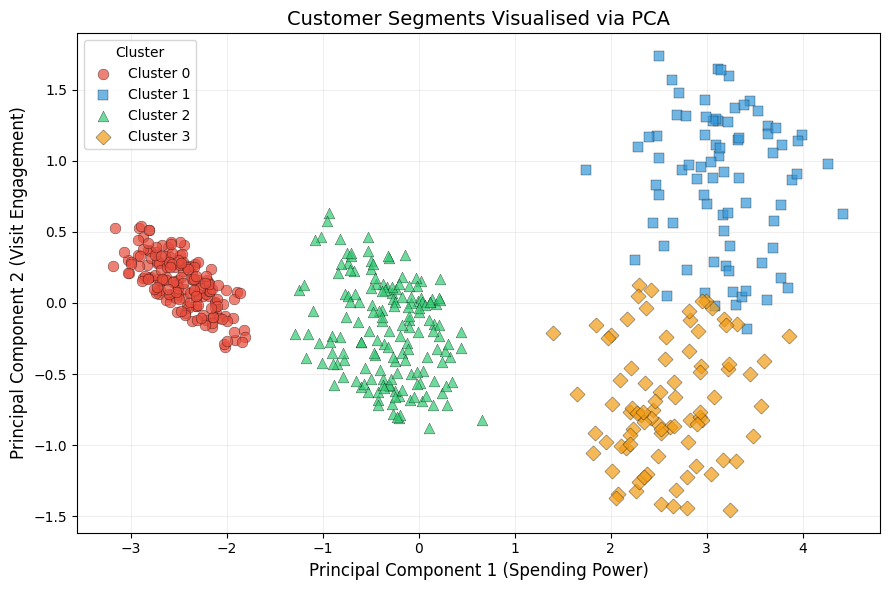

PCA cluster plot saved.


In [7]:
plt.figure(figsize=(9, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
markers = ['o', 's', '^', 'D']

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id], marker=markers[cluster_id],
        label=f'Cluster {cluster_id}', alpha=0.7, s=60, edgecolors='k', linewidths=0.3
    )

plt.xlabel('Principal Component 1 (Spending Power)', fontsize=12)
plt.ylabel('Principal Component 2 (Visit Engagement)', fontsize=12)
plt.title('Customer Segments Visualised via PCA', fontsize=14)
plt.legend(title='Cluster', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('q2_pca_clusters.png', dpi=80, bbox_inches='tight')
plt.show()
print("PCA cluster plot saved.")